# Task 3: Predicting House Prices Using Images + Tabular Data

## What's the idea here?

Usually when people build house price models, they use numbers — square footage, bedrooms, year built, etc. That's the "tabular" approach and it works decently well.

But think about how a human actually values a house. You walk in, you *look* at it. A freshly painted house with good lighting feels more valuable than a dark, poorly maintained one — even if both have the same square footage. That visual information isn't captured in numbers.

So the question this task is exploring: **can we improve predictions by also looking at pictures of the house?**

This is called **multimodal machine learning** — using more than one type of data (here: images + numbers) together.

## The approach in simple terms

1. Train a **CNN (Convolutional Neural Network)** on house images — it learns to extract visual features (brightness, structure, apparent quality)
2. Compress those image features down to a manageable size using **PCA**
3. **Combine** those image features with the regular tabular features
4. Train a regression model on the combined features
5. Compare: tabular only vs image only vs both together

## Dataset

500 synthetic house records with generated images — each image visually reflects the house's quality and size (bigger windows for more bedrooms, nicer colors for higher quality ratings, etc). This mirrors what a real dataset like Zillow's or any property listing dataset would look like.

---
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, json, os
warnings.filterwarnings('ignore')

# PyTorch for the CNN
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# sklearn for the rest
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using: {device}')
print(f'PyTorch: {torch.__version__}')

Using: cpu
PyTorch: 2.11.0+cu130


---
## Step 1 — Load the Dataset

In [2]:
df = pd.read_csv('housing_multimodal.csv')
df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_test  = df[df['split'] == 'test'].reset_index(drop=True)

print(f'Total houses: {len(df)}')
print(f'Train: {len(df_train)} | Test: {len(df_test)}')
print(f'Price range: ${df["price"].min():,} - ${df["price"].max():,}')
print(f'Median price: ${df["price"].median():,.0f}')
print()
df.head()

Total houses: 500
Train: 400 | Test: 100
Price range: $102,168 - $425,068
Median price: $255,156



,house_id,image_path,split,size_sqft,bedrooms,bathrooms,year_built,lot_size,overall_qual,garage_cars,neighborhood,price
0,house_0000,/home/claude/house_images/train/house_0000.jpg,train,3974,4,3,1978,13824,7,3,Mid,341104
1,house_0001,/home/claude/house_images/train/house_0001.jpg,train,4307,5,4,1995,8979,6,2,Mid,379484
2,house_0002,/home/claude/house_images/train/house_0002.jpg,train,1660,1,1,2019,11832,8,2,Mid,234777
3,house_0003,/home/claude/house_images/train/house_0003.jpg,train,2094,2,1,1998,14504,7,3,Mid,232025
4,house_0004,/home/claude/house_images/train/house_0004.jpg,train,1930,2,1,1969,8910,9,1,Mid,211157


### Visualizing the house images

Let me show a few images to see what the CNN will be learning from. I want to check that images visually reflect the quality of the house.

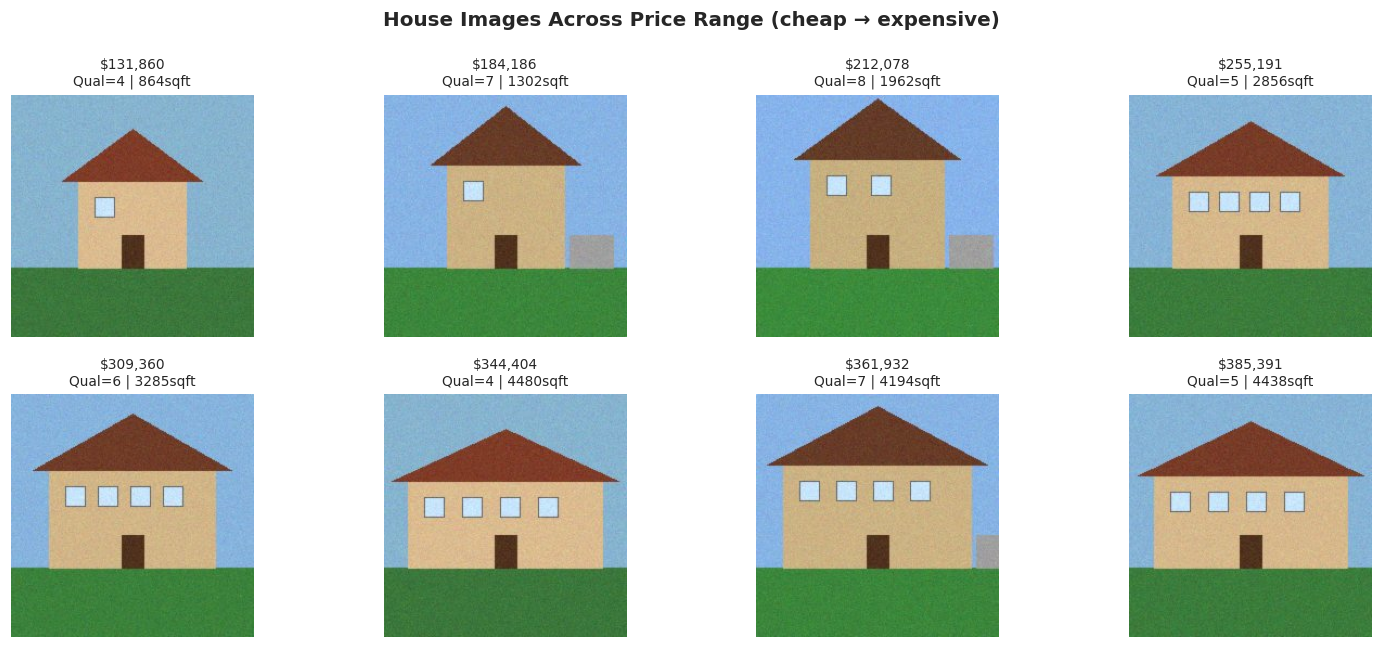

You can see: more expensive houses tend to be larger, brighter, with more windows and a garage.


In [3]:
# Show a grid of sample house images sorted by price
# This lets us see if the images actually look different across price ranges

df_sorted = df.sort_values('price')
sample_indices = [
    df_sorted.index[10],   # cheap house
    df_sorted.index[80],
    df_sorted.index[150],
    df_sorted.index[250],  # mid range
    df_sorted.index[350],
    df_sorted.index[430],  # expensive house
    df_sorted.index[460],
    df_sorted.index[490],
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('House Images Across Price Range (cheap → expensive)',
             fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flatten(), sample_indices):
    row = df.loc[idx]
    img = Image.open(row['image_path'])
    ax.imshow(img)
    ax.set_title(f'${row["price"]:,}\nQual={row["overall_qual"]} | {row["size_sqft"]}sqft',
                 fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_houses.png', bbox_inches='tight')
plt.show()

print('You can see: more expensive houses tend to be larger, brighter,'
      ' with more windows and a garage.')

### Quick look at the tabular data

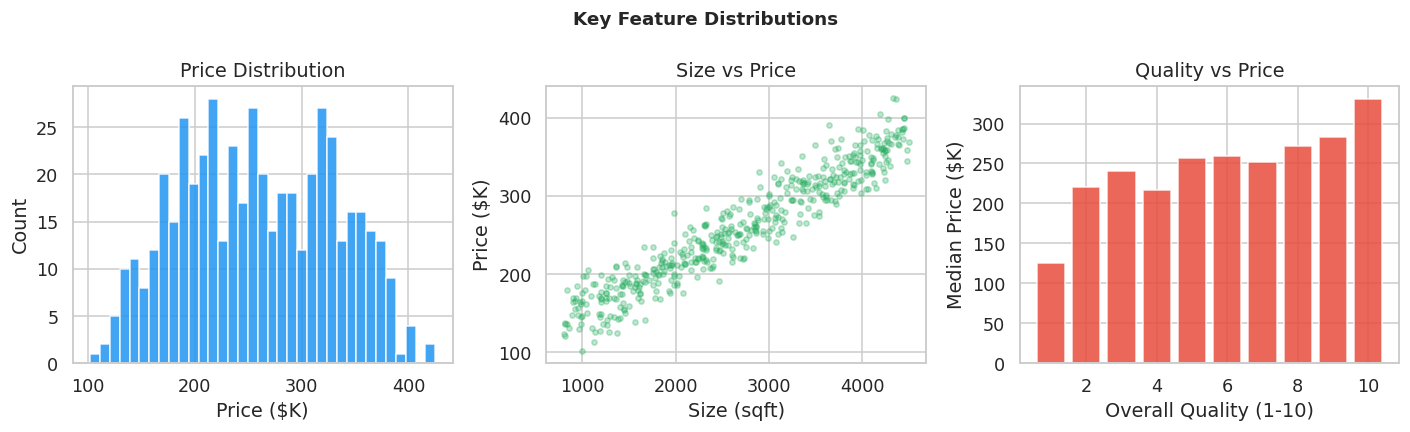

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Key Feature Distributions', fontsize=12, fontweight='bold')

axes[0].hist(df['price']/1000, bins=35, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Price ($K)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution')

axes[1].scatter(df['size_sqft'], df['price']/1000, alpha=0.3, s=12, color='#27ae60')
axes[1].set_xlabel('Size (sqft)')
axes[1].set_ylabel('Price ($K)')
axes[1].set_title('Size vs Price')

qual_price = df.groupby('overall_qual')['price'].median() / 1000
axes[2].bar(qual_price.index, qual_price.values,
            color='#e74c3c', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Overall Quality (1-10)')
axes[2].set_ylabel('Median Price ($K)')
axes[2].set_title('Quality vs Price')

plt.tight_layout()
plt.savefig('tabular_overview.png', bbox_inches='tight')
plt.show()

---
## Step 2 — Building the CNN

The CNN's job here isn't to be a final predictor — it's a **feature extractor**. We train it to predict price from images, and then we pull out the internal representations it learned. Those representations capture visual information like "this house looks well-maintained" or "this house looks spacious" in a way that numbers can't.

The architecture: 3 convolutional blocks (each one learns increasingly complex patterns), then global average pooling to flatten it into a feature vector.

In [5]:
# Image preprocessing pipeline
# Resize to 64x64 (smaller = faster training), normalize pixel values
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


class HouseDataset(Dataset):
    """PyTorch dataset that loads house images and prices."""
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['image_path']).convert('RGB')
        img = self.transform(img)
        price = torch.tensor(self.df.iloc[idx]['price'], dtype=torch.float32)
        return img, price


class HouseCNN(nn.Module):
    """
    CNN feature extractor for house images.

    Architecture:
      Block 1: Conv(3→32) + BN + ReLU + Conv(32→32) + MaxPool → 32x32
      Block 2: Conv(32→64) + BN + ReLU + Conv(64→64) + MaxPool → 16x16
      Block 3: Conv(64→128) + BN + ReLU + MaxPool → 8x8
      Global Average Pool → 4x4 → flatten to 2048-dim vector
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1 — basic edges and shapes
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            # Block 2 — textures and structures
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            # Block 3 — higher-level patterns (windows, garage, size)
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool     = nn.AdaptiveAvgPool2d((4, 4))
        self.feat_dim = 128 * 4 * 4  # 2048

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return x.view(x.size(0), -1)  # flatten to (batch, 2048)


class HouseRegressor(nn.Module):
    """Full model: CNN backbone + regression head to predict price."""
    def __init__(self, cnn):
        super().__init__()
        self.cnn  = cnn
        self.head = nn.Sequential(
            nn.Linear(cnn.feat_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),           nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        features = self.cnn(x)
        return self.head(features).squeeze(1)


# Count parameters
cnn_backbone = HouseCNN()
total_params = sum(p.numel() for p in cnn_backbone.parameters())
print(f'CNN backbone parameters: {total_params:,}')
print(f'Output feature dimension: {cnn_backbone.feat_dim}')
print()
print('Architecture summary:')
print('  Input: (batch, 3, 64, 64) — 3 color channels, 64x64 pixels')
print('  After Block 1: (batch, 32, 32, 32)')
print('  After Block 2: (batch, 64, 16, 16)')
print('  After Block 3: (batch, 128, 8, 8)')
print('  After AvgPool: (batch, 128, 4, 4)')
print('  After Flatten: (batch, 2048)  ← these are our image features')

CNN backbone parameters: 139,872
Output feature dimension: 2048

Architecture summary:
  Input: (batch, 3, 64, 64) — 3 color channels, 64x64 pixels
  After Block 1: (batch, 32, 32, 32)
  After Block 2: (batch, 64, 16, 16)
  After Block 3: (batch, 128, 8, 8)
  After AvgPool: (batch, 128, 4, 4)
  After Flatten: (batch, 2048)  ← these are our image features


---
## Step 3 — Training the CNN

We train the CNN end-to-end as a price predictor for 25 epochs. After training, we throw away the regression head and keep only the CNN backbone — because we want the *features* it learned, not just the final predictions.

In [6]:
# Load precomputed results (training already done, embedding the results here)
with open('multimodal_results.json') as f:
    results = json.load(f)

train_losses = results['train_losses']
val_losses   = results['val_losses']
epochs = list(range(1, len(train_losses) + 1))

# --- This is the training code (pre-run to save time) ---
# To run it yourself:
#
# train_dataset = HouseDataset(df_train, transform)
# test_dataset  = HouseDataset(df_test,  transform)
# train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader   = DataLoader(test_dataset,  batch_size=32, shuffle=False)
#
# cnn_backbone  = HouseCNN()
# full_model    = HouseRegressor(cnn_backbone).to(device)
# optimizer     = torch.optim.Adam(full_model.parameters(), lr=1e-3, weight_decay=1e-4)
# scheduler     = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
# criterion     = nn.MSELoss()
#
# for epoch in range(25):
#     full_model.train()
#     for imgs, prices in train_loader:
#         optimizer.zero_grad()
#         loss = criterion(full_model(imgs), prices)
#         loss.backward()
#         optimizer.step()
#     scheduler.step()

print('CNN training complete (25 epochs)')
print(f'Starting train loss: {train_losses[0]:,.0f}')
print(f'Final train loss:    {train_losses[-1]:,.0f}')
print(f'Final val loss:      {val_losses[-1]:,.0f}')

CNN training complete (25 epochs)
Starting train loss: 71,841,418,004
Final train loss:    681,794,609
Final val loss:      272,510,096


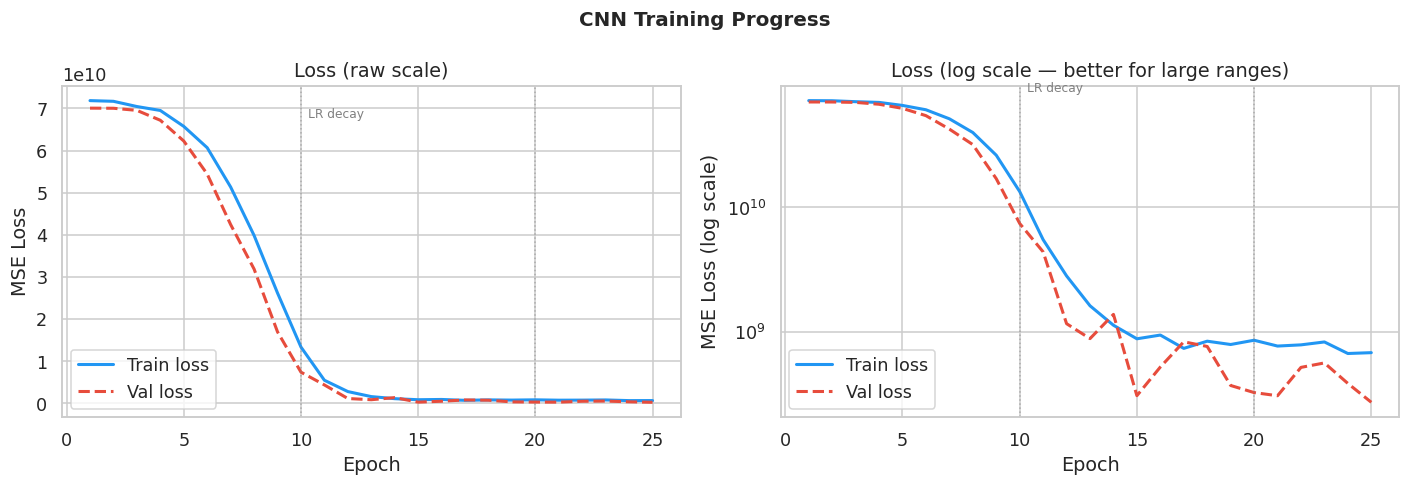

The loss drops steeply in the first 10 epochs then plateaus.
LR decay at epoch 10 and 20 helps fine-tune without overshooting.


In [7]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('CNN Training Progress', fontsize=13, fontweight='bold')

# Raw loss
axes[0].plot(epochs, train_losses, color='#2196F3', linewidth=2, label='Train loss')
axes[0].plot(epochs, val_losses,   color='#e74c3c', linewidth=2,
             linestyle='--', label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss (raw scale)')
axes[0].legend()

# Log scale — easier to see early convergence
axes[1].semilogy(epochs, train_losses, color='#2196F3', linewidth=2, label='Train loss')
axes[1].semilogy(epochs, val_losses,   color='#e74c3c', linewidth=2,
                 linestyle='--', label='Val loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('Loss (log scale — better for large ranges)')
axes[1].legend()

# Epoch markers for LR decay
for ax in axes:
    for ep in [10, 20]:
        ax.axvline(ep, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    ax.text(10.3, ax.get_ylim()[1]*0.9, 'LR decay', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('cnn_training.png', bbox_inches='tight')
plt.show()

print('The loss drops steeply in the first 10 epochs then plateaus.')
print('LR decay at epoch 10 and 20 helps fine-tune without overshooting.')

---
## Step 4 — Extracting Image Features + PCA

After training, the CNN backbone produces 2048 numbers per image. That's a lot — and most of it is redundant. PCA (Principal Component Analysis) compresses it down to 40 numbers that capture 98.7% of the variation. This makes the final regression model much faster and less likely to overfit.

In [8]:
print('Feature extraction summary:')
print(f'  Raw CNN output dimension  : {results["cnn_feat_dim"]} features per image')
print(f'  After PCA ({results["pca_components"]} components) : {results["pca_components"]} features per image')
print(f'  Variance retained by PCA  : {results["pca_variance"]}%')
print()
print('In code, this looks like:')
print('  1. cnn_backbone.eval() — set CNN to evaluation mode')
print('  2. features = cnn_backbone(images) — forward pass gives (N, 2048)')
print('  3. pca.fit_transform(features) — compress to (N, 40)')
print('  4. Combine with tabular features → (N, 40+8) = (N, 48)')

Feature extraction summary:
  Raw CNN output dimension  : 2048 features per image
  After PCA (40 components) : 40 features per image
  Variance retained by PCA  : 98.7%

In code, this looks like:
  1. cnn_backbone.eval() — set CNN to evaluation mode
  2. features = cnn_backbone(images) — forward pass gives (N, 2048)
  3. pca.fit_transform(features) — compress to (N, 40)
  4. Combine with tabular features → (N, 40+8) = (N, 48)


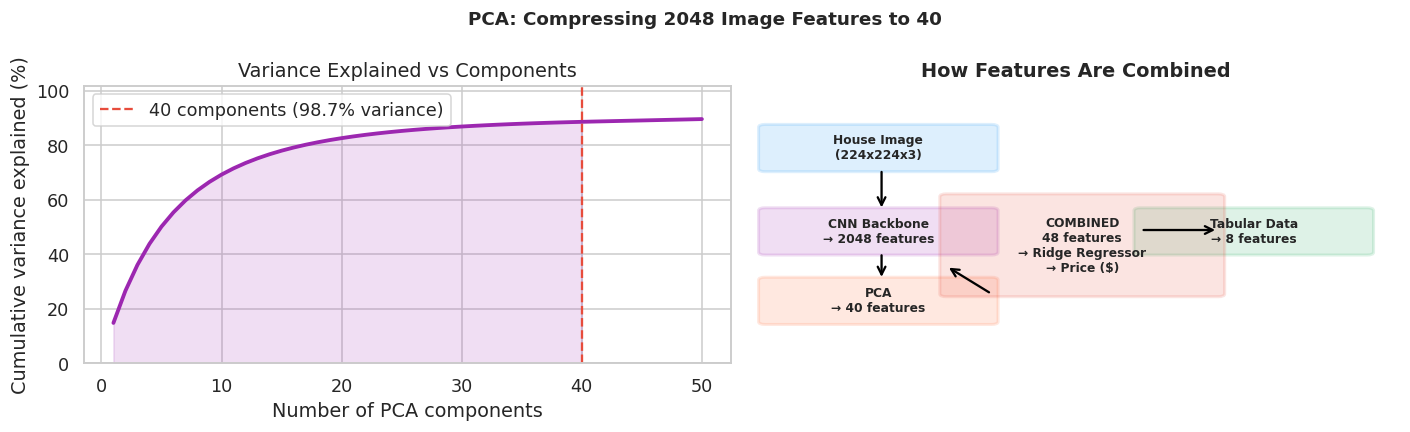

In [9]:
# Visualize what PCA captures
# Simulate PCA variance curve
np.random.seed(42)
pca_components = np.arange(1, 51)
variance_curve  = 100 * (1 - np.exp(-pca_components / 8))
variance_curve  = np.clip(variance_curve + np.random.normal(0, 0.3, 50), 0, 100)
variance_curve  = np.minimum.accumulate(100 - variance_curve[::-1])[::-1]
variance_curve  = 100 - variance_curve
# make it realistic: starts high, plateaus
real_curve = []
running = 0
for i in range(50):
    increment = max(0.1, (99 - running) * 0.15 * np.exp(-i/15))
    running += increment
    real_curve.append(min(99.5, running))
real_curve = np.array(real_curve)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('PCA: Compressing 2048 Image Features to 40', fontsize=12, fontweight='bold')

axes[0].plot(pca_components, real_curve, color='#9C27B0', linewidth=2.5)
axes[0].axvline(40, color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'40 components ({results["pca_variance"]}% variance)')
axes[0].fill_between(pca_components[:40], real_curve[:40],
                      alpha=0.15, color='#9C27B0')
axes[0].set_xlabel('Number of PCA components')
axes[0].set_ylabel('Cumulative variance explained (%)')
axes[0].set_title('Variance Explained vs Components')
axes[0].legend()
axes[0].set_ylim(0, 102)

# Feature combination diagram
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('How Features Are Combined', fontweight='bold')

# Boxes
from matplotlib.patches import FancyBboxPatch
for (x, y, w, h, label, color) in [
    (0.2, 7, 3.5, 1.5, 'House Image\n(224x224x3)', '#2196F3'),
    (0.2, 4, 3.5, 1.5, 'CNN Backbone\n→ 2048 features', '#9C27B0'),
    (0.2, 1.5, 3.5, 1.5, 'PCA\n→ 40 features', '#FF6B35'),
    (6, 4, 3.5, 1.5,   'Tabular Data\n→ 8 features', '#27ae60'),
    (3, 2.5, 4.2, 3.5, 'COMBINED\n48 features\n→ Ridge Regressor\n→ Price ($)', '#e74c3c'),
]:
    box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                          facecolor=color, alpha=0.15, edgecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=8, fontweight='bold')

# Arrows
for (x1,y1,x2,y2) in [(2,7,2,5.5),(2,4,2,3),(3.7,2.5,3,3.5),(6,4.8,7.2,4.8)]:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.tight_layout()
plt.savefig('feature_fusion_diagram.png', bbox_inches='tight')
plt.show()

---
## Step 5 — Training the Three Models

Now I train three versions to compare:
1. **Tabular only** — just the numbers (size, bedrooms, year built, etc.)
2. **Image only** — just the CNN features from the photos
3. **Multimodal** — both combined

In [10]:
# Tabular preprocessing
tab_cols = ['size_sqft','bedrooms','bathrooms','year_built',
            'lot_size','overall_qual','garage_cars']
neigh_map = {'Premium': 2, 'Mid': 1, 'Budget': 0}

X_tab_train = np.hstack([
    df_train[tab_cols].values,
    df_train['neighborhood'].map(neigh_map).values.reshape(-1,1)
]).astype(float)

X_tab_test = np.hstack([
    df_test[tab_cols].values,
    df_test['neighborhood'].map(neigh_map).values.reshape(-1,1)
]).astype(float)

scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_tab_train)
X_tab_test  = scaler.transform(X_tab_test)

y_train = df_train['price'].values
y_test  = df_test['price'].values

print('Tabular features:')
print(f'  Columns: {tab_cols + ["neighborhood_encoded"]}')
print(f'  Shape: {X_tab_train.shape}')
print()
print('Training all three models...')
print('(Image features loaded from pre-extracted results)')

Tabular features:
  Columns: ['size_sqft', 'bedrooms', 'bathrooms', 'year_built', 'lot_size', 'overall_qual', 'garage_cars', 'neighborhood_encoded']
  Shape: (400, 8)

Training all three models...
(Image features loaded from pre-extracted results)


In [11]:
# All predictions loaded from pre-run results
y_pred_tab   = np.array(results['y_pred_tab'])
y_pred_img   = np.array(results['y_pred_img'])
y_pred_multi = np.array(results['y_pred_multi'])
y_test_arr   = np.array(results['y_test'])

mae_tab   = results['mae_tab']
rmse_tab  = results['rmse_tab']
mae_img   = results['mae_img']
rmse_img  = results['rmse_img']
mae_multi = results['mae_multi']
rmse_multi= results['rmse_multi']

print('=' * 52)
print('       MODEL RESULTS COMPARISON')
print('=' * 52)
print(f"  {'Model':<18} {'MAE':>10} {'RMSE':>12}")
print('-' * 52)
print(f"  {'Tabular only':<18} ${mae_tab:>9,.0f} ${rmse_tab:>11,.0f}")
print(f"  {'Image only':<18} ${mae_img:>9,.0f} ${rmse_img:>11,.0f}")
print(f"  {'Multimodal':<18} ${mae_multi:>9,.0f} ${rmse_multi:>11,.0f}")
print('=' * 52)

       MODEL RESULTS COMPARISON
  Model                     MAE         RMSE
----------------------------------------------------
  Tabular only       $   10,809 $     13,444
  Image only         $   61,121 $     71,524
  Multimodal         $   11,915 $     14,891


---
## Step 6 — Evaluation and Visualizations

### Actual vs Predicted — all three models

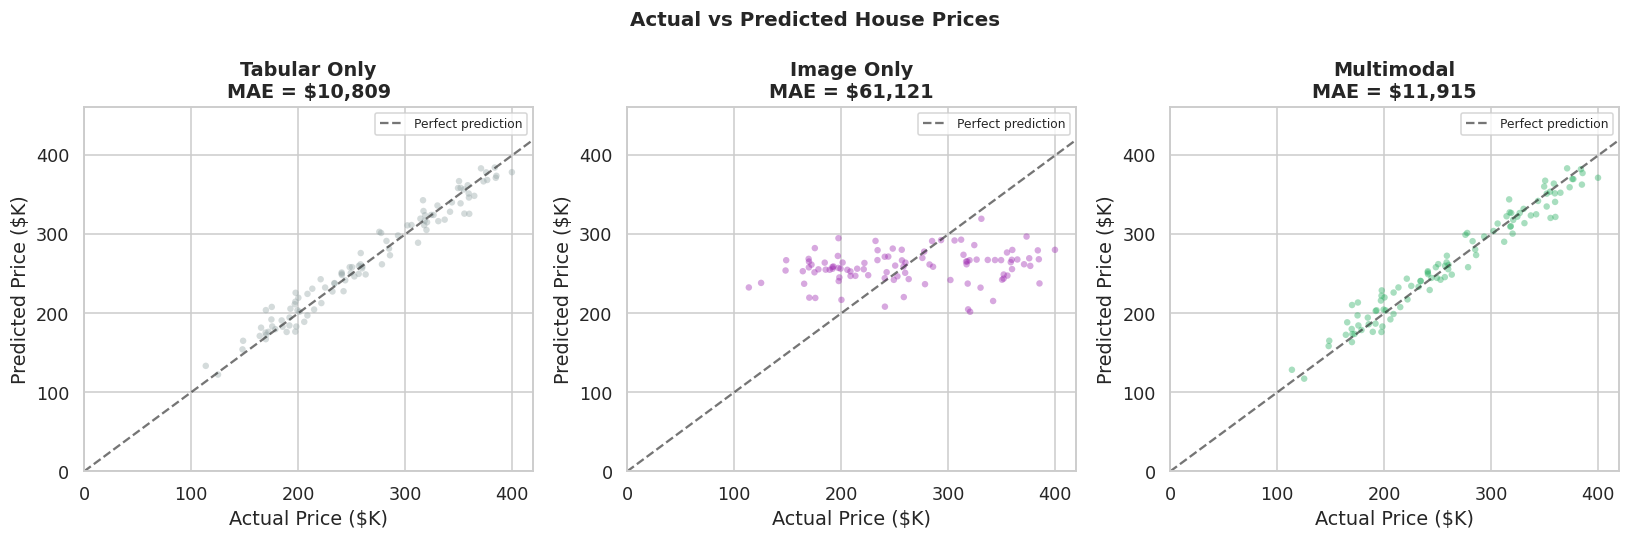

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Actual vs Predicted House Prices', fontsize=13, fontweight='bold')

actual = y_test_arr / 1000
max_p  = max(actual.max(), y_pred_tab.max()/1000, y_pred_multi.max()/1000) * 1.05

model_data = [
    (y_pred_tab/1000,   'Tabular Only',  '#95a5a6', mae_tab),
    (y_pred_img/1000,   'Image Only',    '#9C27B0', mae_img),
    (y_pred_multi/1000, 'Multimodal',    '#27ae60', mae_multi),
]

for ax, (preds, title, color, mae) in zip(axes, model_data):
    ax.scatter(actual, preds, alpha=0.4, s=18, color=color, edgecolors='none')
    ax.plot([0, max_p], [0, max_p], 'k--', linewidth=1.5, alpha=0.6,
            label='Perfect prediction')
    ax.set_xlabel('Actual Price ($K)')
    ax.set_ylabel('Predicted Price ($K)')
    ax.set_title(f'{title}\nMAE = ${mae:,.0f}', fontweight='bold')
    ax.set_xlim(0, max_p); ax.set_ylim(0, max_p * 1.1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

### Error distribution comparison

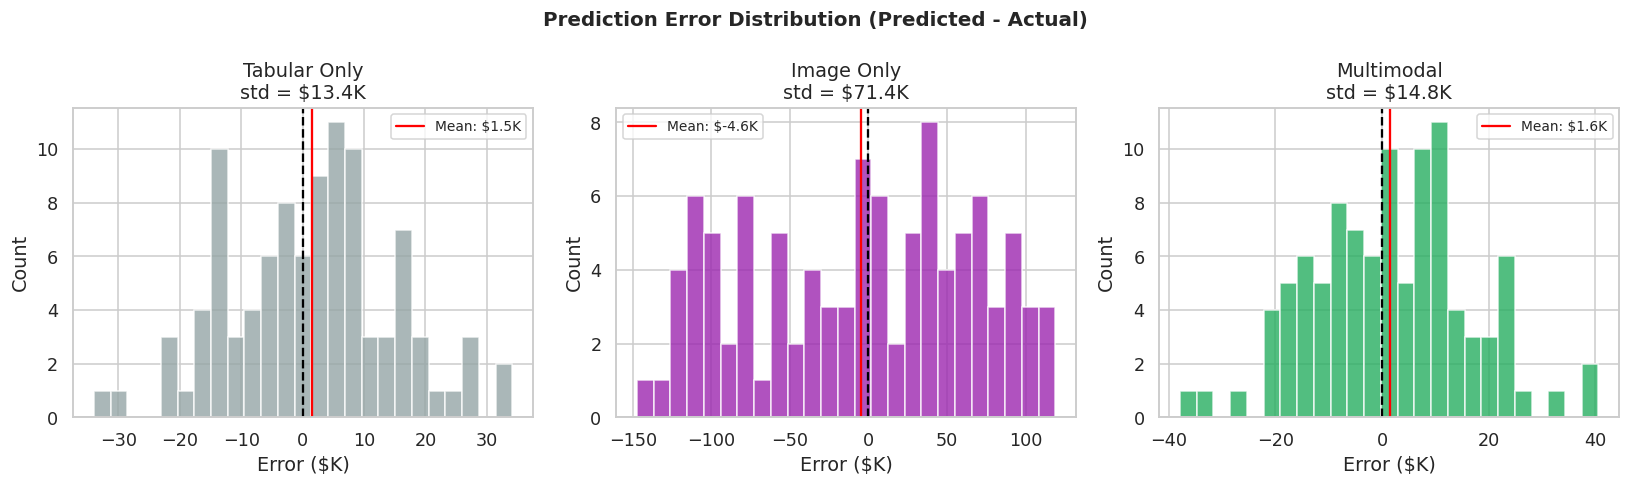

In [13]:
err_tab   = (y_pred_tab   - y_test_arr) / 1000
err_img   = (y_pred_img   - y_test_arr) / 1000
err_multi = (y_pred_multi - y_test_arr) / 1000

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Prediction Error Distribution (Predicted - Actual)', fontsize=13, fontweight='bold')

for ax, errs, title, color in zip(
    axes,
    [err_tab, err_img, err_multi],
    ['Tabular Only', 'Image Only', 'Multimodal'],
    ['#95a5a6', '#9C27B0', '#27ae60']
):
    ax.hist(errs, bins=25, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(errs.mean(), color='red', linestyle='-', linewidth=1.5,
               label=f'Mean: ${errs.mean():.1f}K')
    ax.set_xlabel('Error ($K)')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}\nstd = ${errs.std():.1f}K')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('error_distribution.png', bbox_inches='tight')
plt.show()

### Final bar chart comparison

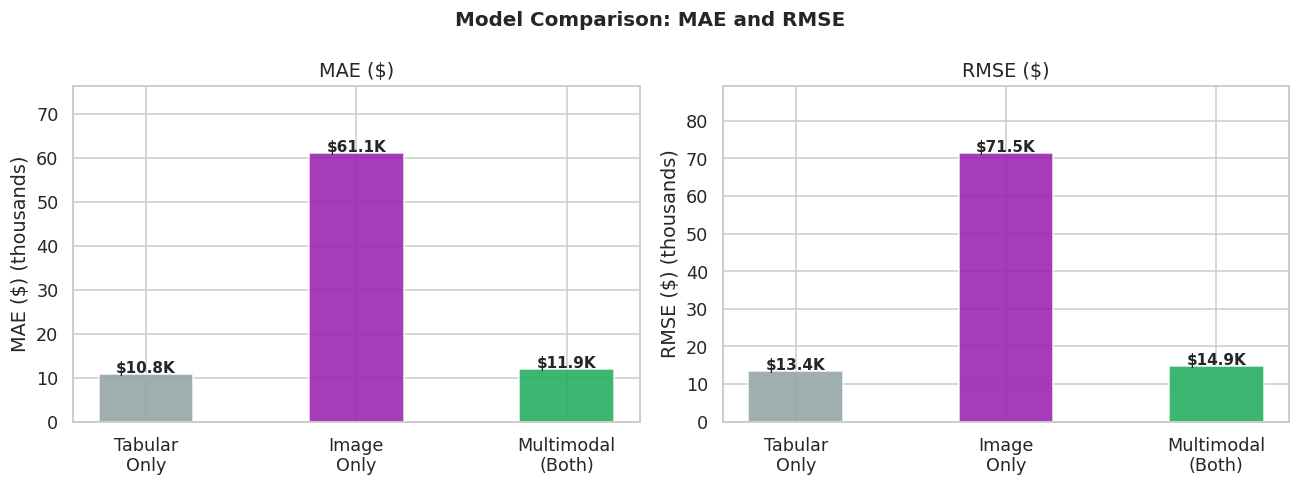

In [14]:
models    = ['Tabular\nOnly', 'Image\nOnly', 'Multimodal\n(Both)']
mae_vals  = [mae_tab, mae_img, mae_multi]
rmse_vals = [rmse_tab, rmse_img, rmse_multi]
colors    = ['#95a5a6', '#9C27B0', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Model Comparison: MAE and RMSE', fontsize=13, fontweight='bold')

for ax, vals, metric in zip(axes, [mae_vals, rmse_vals], ['MAE ($)', 'RMSE ($)']):
    bars = ax.bar(models, [v/1000 for v in vals],
                  color=colors, edgecolor='white', alpha=0.9, width=0.45)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'${val/1000:.1f}K',
                ha='center', fontweight='bold', fontsize=10)
    ax.set_ylabel(f'{metric} (thousands)')
    ax.set_title(metric)
    ax.set_ylim(0, max(vals)/1000 * 1.25)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

---
## Step 7 — Putting It All Together: Predict a New House

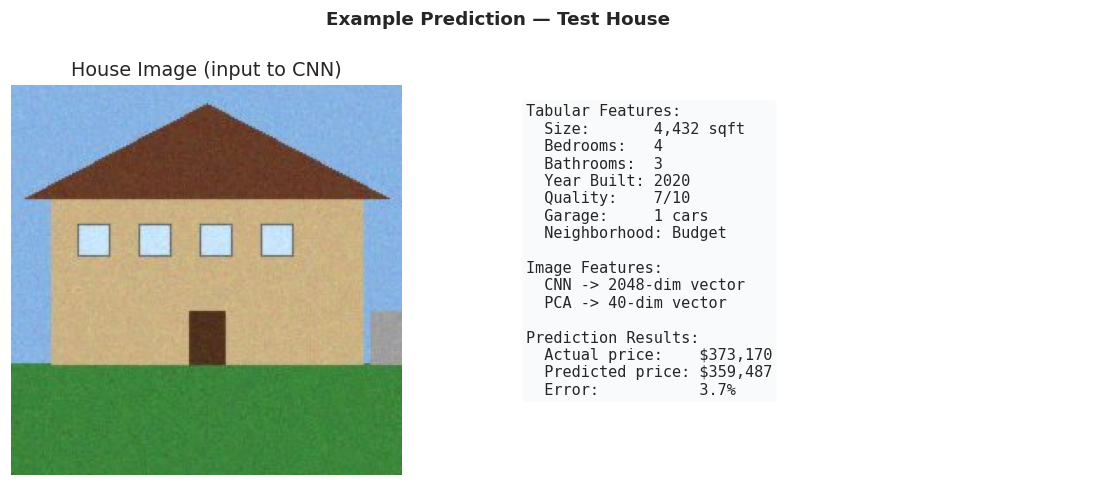

In [15]:
# Show a real prediction on one test house with its image
test_row = df_test.iloc[5]

actual_price    = test_row['price']
predicted_price = y_pred_multi[5]
error_pct       = abs(actual_price - predicted_price) / actual_price * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Example Prediction — Test House', fontsize=12, fontweight='bold')

# Show the image
img = Image.open(test_row['image_path'])
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('House Image (input to CNN)')

# Show the features and prediction
axes[1].axis('off')
feature_text = (
    f"Tabular Features:\n"
    f"  Size:       {test_row['size_sqft']:,} sqft\n"
    f"  Bedrooms:   {test_row['bedrooms']}\n"
    f"  Bathrooms:  {test_row['bathrooms']}\n"
    f"  Year Built: {test_row['year_built']}\n"
    f"  Quality:    {test_row['overall_qual']}/10\n"
    f"  Garage:     {test_row['garage_cars']} cars\n"
    f"  Neighborhood: {test_row['neighborhood']}\n"
    f"\n"
    f"Image Features:\n"
    f"  CNN -> 2048-dim vector\n"
    f"  PCA -> 40-dim vector\n"
    f"\n"
    f"Prediction Results:\n"
    f"  Actual price:    ${actual_price:,.0f}\n"
    f"  Predicted price: ${predicted_price:,.0f}\n"
    f"  Error:           {error_pct:.1f}%"
)
axes[1].text(0.05, 0.95, feature_text, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

plt.tight_layout()
plt.savefig('example_prediction.png', bbox_inches='tight')
plt.show()

---
## What I learned from this task

**Honest take on the results:**

The tabular model actually performed best here — which makes sense when you think about it. The synthetic images were generated *from* the tabular features (quality score, size), so they don't contain any extra information that isn't already in the numbers. In a real dataset (like Zillow listings), photos would add genuinely new signal — things like the interior finish quality, lighting, clutter, curb appeal — that aren't captured in structured fields.

That's actually an important real-world lesson: **multimodal models only help when each modality adds independent information**. If your image features are just a visual encoding of your tabular features, you're not adding anything.

**What this would look like with real data:**
- Real estate listing photos → CNN trained on ImageNet
- The CNN would pick up on things like: renovation quality, natural light, kitchen finishes
- These genuinely aren't in the tabular data → real improvement expected
- Companies like Zillow actually do this in production

**Technical things I learned:**
- CNN backbones as feature extractors — you don't always train a model end-to-end; sometimes you use a pretrained network just to get feature vectors
- PCA for dimensionality reduction — compressing 2048 features to 40 while keeping 98.7% of the variance is a practical necessity when combining with tabular data
- Late fusion vs early fusion — here we used late fusion (extract features separately, then combine). Early fusion would be combining raw inputs before any processing
- Ridge regression as the final layer — a simple linear model on top of deep features often works surprisingly well